In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import math 
import plotly.express as px
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flipkart-fasion-products-dataset/output.xlsx
/kaggle/input/flipkart-fasion-products-dataset/flipkart_fashion_products_dataset.json


In [2]:
df = pd.read_excel("/kaggle/input/flipkart-fasion-products-dataset/output.xlsx")
df.head()

,Unnamed: 0,_id,actual_price,average_rating,brand,category,crawled_at,description,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url
0,0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
1,1,893e6980-f2a0-531f-b056-34dd63fe912c,"1,499",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...
2,2,eb4c8eab-8206-59d0-bcd1-a724d96bf74f,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",68% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EHFCY5Z4Y,"[{'Style Code': '1005COMBO4'}, {'Closure': 'El...",Shyam Enterprises,931,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
3,3,3f3f97bb-5faf-57df-a9ff-1af24e2b1045,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:53",69% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9ESZZ7YWEF,"[{'Style Code': '1005COMBO3'}, {'Closure': 'El...",Shyam Enterprises,911,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
4,4,750caa3d-6264-53ca-8ce1-94118a1d8951,"2,999",3.9,York,Clothing and Accessories,"02/10/2021, 20:11:53",68% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EVXKBSUD7,"[{'Style Code': '1005COMBO1'}, {'Closure': 'Dr...",Shyam Enterprises,943,Bottomwear,"Solid Men Brown, Grey Track Pants",https://www.flipkart.com/yorker-solid-men-brow...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30000 non-null  int64  
 1   _id              30000 non-null  object 
 2   actual_price     29137 non-null  object 
 3   average_rating   27554 non-null  float64
 4   brand            27932 non-null  object 
 5   category         30000 non-null  object 
 6   crawled_at       30000 non-null  object 
 7   description      29059 non-null  object 
 8   discount         18017 non-null  object 
 9   images           30000 non-null  object 
 10  out_of_stock     30000 non-null  bool   
 11  pid              30000 non-null  object 
 12  product_details  30000 non-null  object 
 13  seller           28259 non-null  object 
 14  selling_price    29998 non-null  object 
 15  sub_category     30000 non-null  object 
 16  title            30000 non-null  object 
 17  url         

In [4]:
def data(df):
    missing_values = df.isnull().sum()
    duplicated_rows = df.duplicated().sum()
    unique_values = df.nunique().sum()
    
    
    object = pd.DataFrame({
        "Missing values ": missing_values,
        "Duplcaited values ": duplicated_rows,
        "Unique values": unique_values
    })
    
    return object


In [5]:
data_info = data(df)

# Set the display options
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns

data_info

,Missing values,Duplcaited values,Unique values
Unnamed: 0,0,0,199221
_id,0,0,199221
actual_price,863,0,199221
average_rating,2446,0,199221
brand,2068,0,199221
category,0,0,199221
crawled_at,0,0,199221
description,941,0,199221
discount,11983,0,199221
images,0,0,199221


# *Market Anlaysis* 

<span style="color:blue; font-size:32px">Category analysis:</span>


### *Here We* ,

Analyze the "category" and "sub_category" columns to identify the distribution of products across different categories and sub-categories. Determine which categories are most popular and explore any emerging trends or shifts in consumer preferences.

In [6]:
def plot(df, figsize, subplot, pie_data,pie_data2):
    plt.figure(figsize=figsize)

    # Plot histograms
    for index, column in enumerate(df.columns):
        plt.subplot(*subplot, index+1)
        sns.histplot(df[column])
        plt.xticks(rotation='vertical')
    
    # Plot pie chart
    plt.subplot(*subplot, len(df.columns)+1)
    labels = pie_data.index
    sizes = pie_data.values
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    
    total = sum(sizes)
    percentage_labels = [f"{label}: {size/total*100:.1f}%" for label, size in zip(labels, sizes)]
    plt.legend(labels=percentage_labels, loc='upper left')
    
    plt.subplot(*subplot, len(df.columns)+2)
    labels = pie_data2.index
    sizes = pie_data2.values
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    
    total = sum(sizes)
    percentage_labels = [f"{label}: {size/total*100:.1f}%" for label, size in zip(labels, sizes)]
    plt.legend(labels=percentage_labels, loc='upper left')
    
    
    plt.tight_layout()
    plt.show()



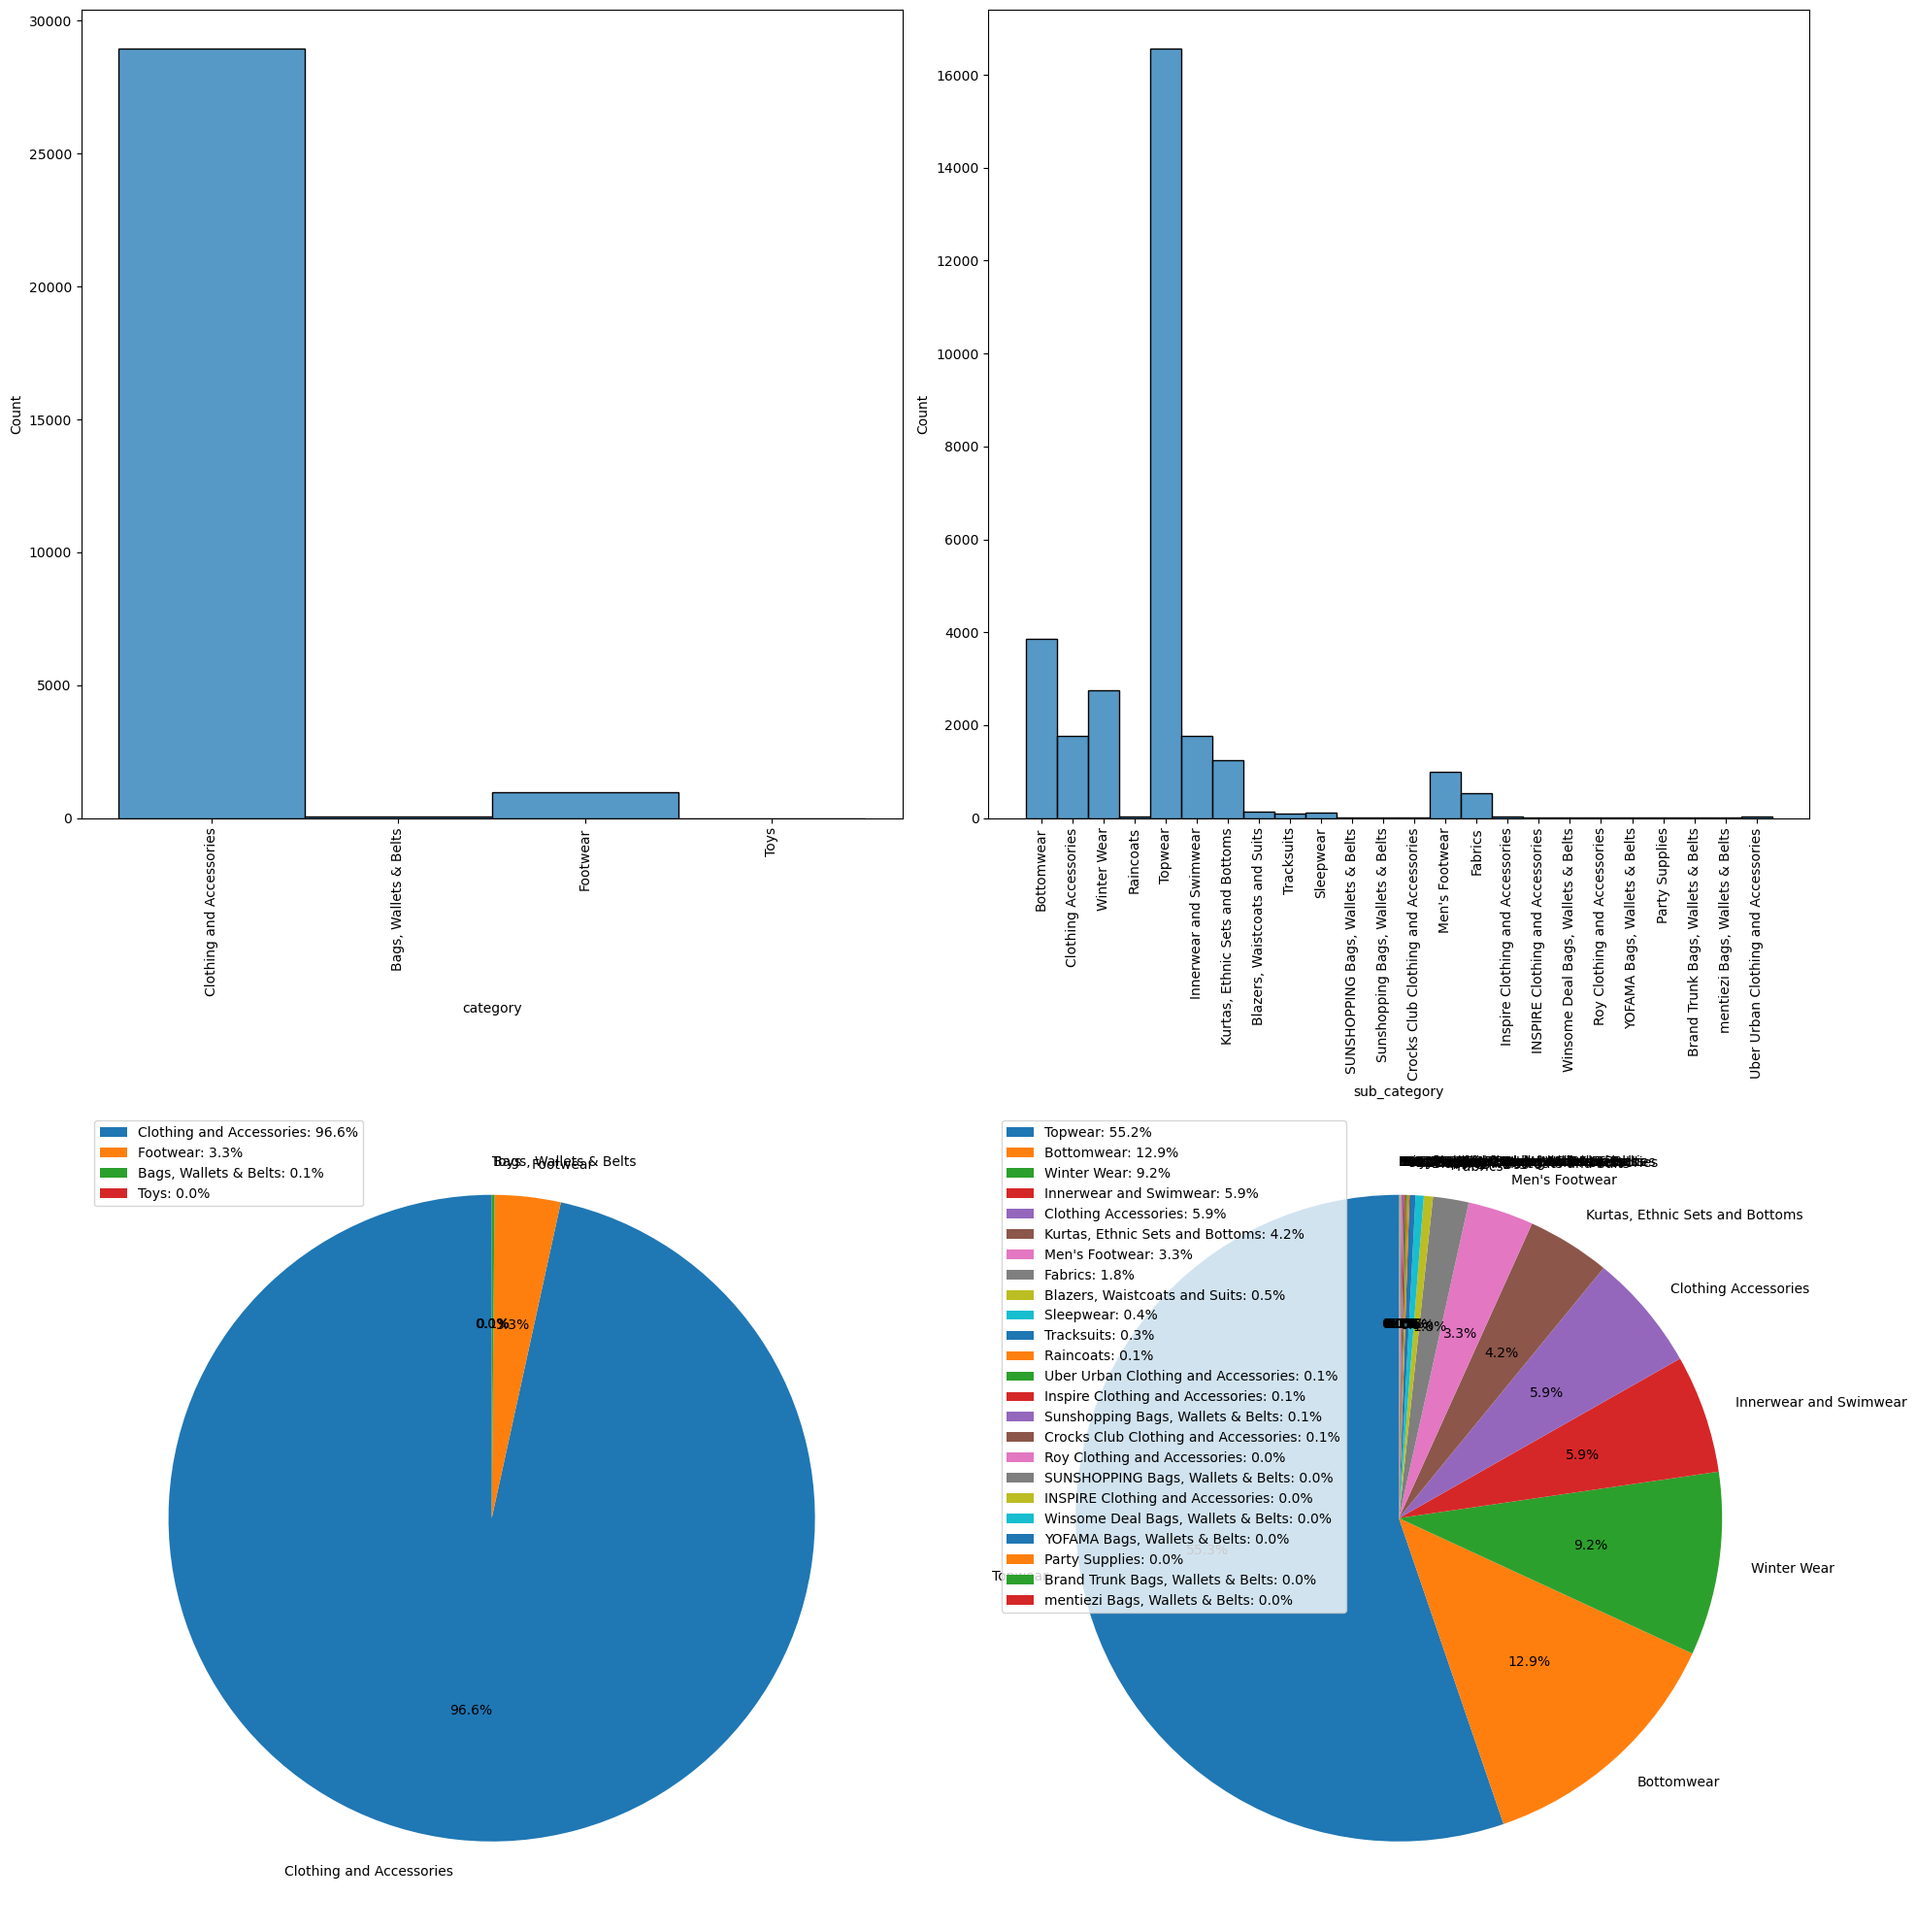

In [7]:
plot(df[['category', 'sub_category']], (20,20 ), (2, 2), df['category'].value_counts(),df['sub_category'].value_counts())


# *Observation*

<div style="border:1px solid black; padding:10px">
    
<span style="color:green; font-size:32px">Category analysis:</span>

* ### *Based on the plots above we can clearly see that the most frequent category is clothing and accessories*

* ### *We can also see that in the plot for sub category as well*

</div>




# Brand Analysis 
<span style="color:red; font-size:32px">Brand analysis:</span>
## *Here we* , 
Investigate the "brand" column to understand the market presence of different brands. Identify popular brands, assess brand loyalty, and analyze customer preferences towards specific brands.

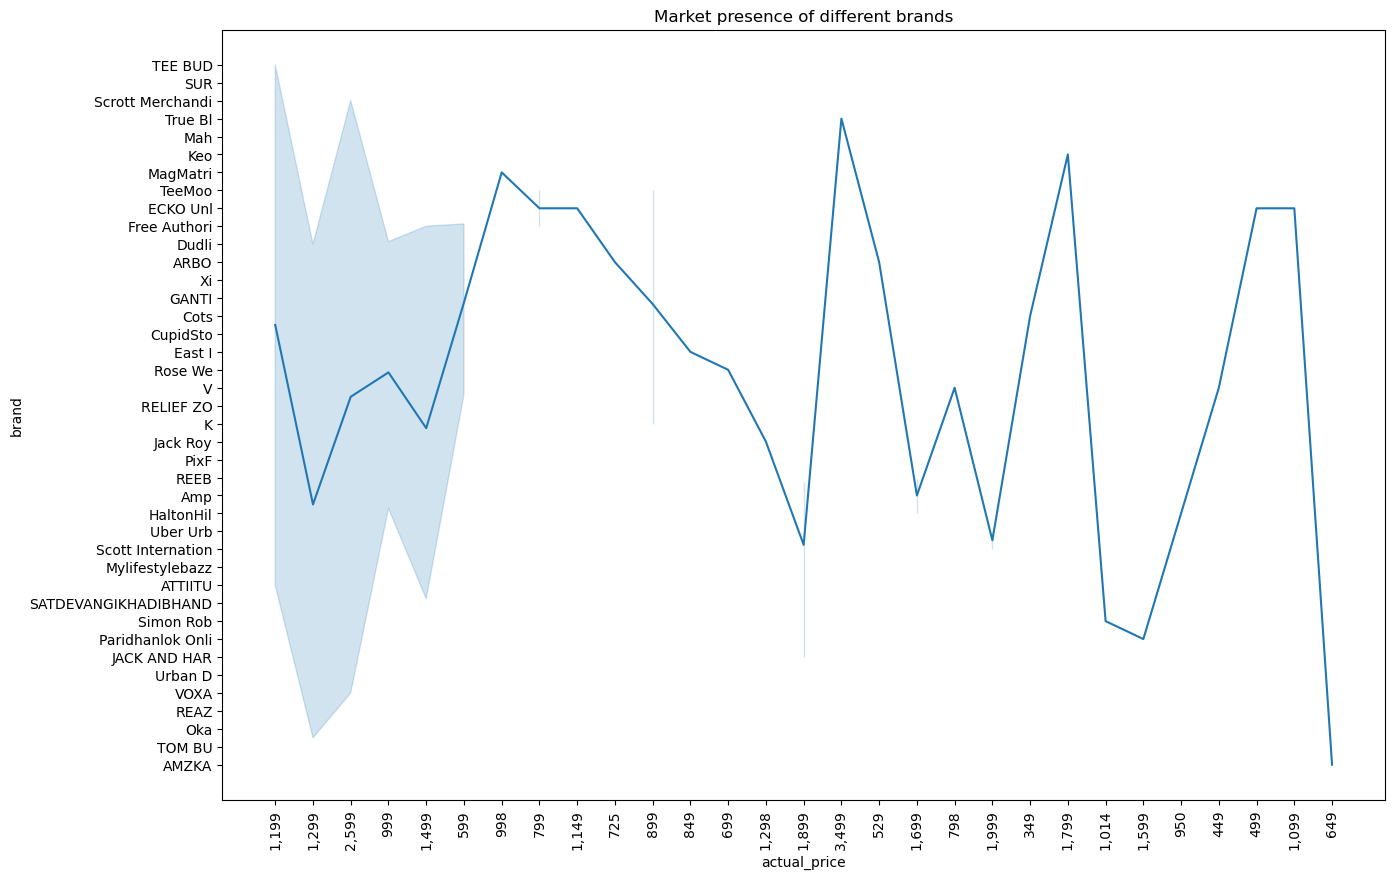

In [8]:
# we take a allsample brand and try seeing if based on the brand does the price rise
plt.figure(figsize=(15, 10))

# Subsample the data for better visualization
subset_df = df.sample(n=60)  # Adjust the number of samples as needed

# Line plot for 'brand'

sns.lineplot(data=subset_df, x='actual_price', y='brand')
plt.xticks(rotation='vertical')
plt.title("Market presence of different brands")
plt.show()

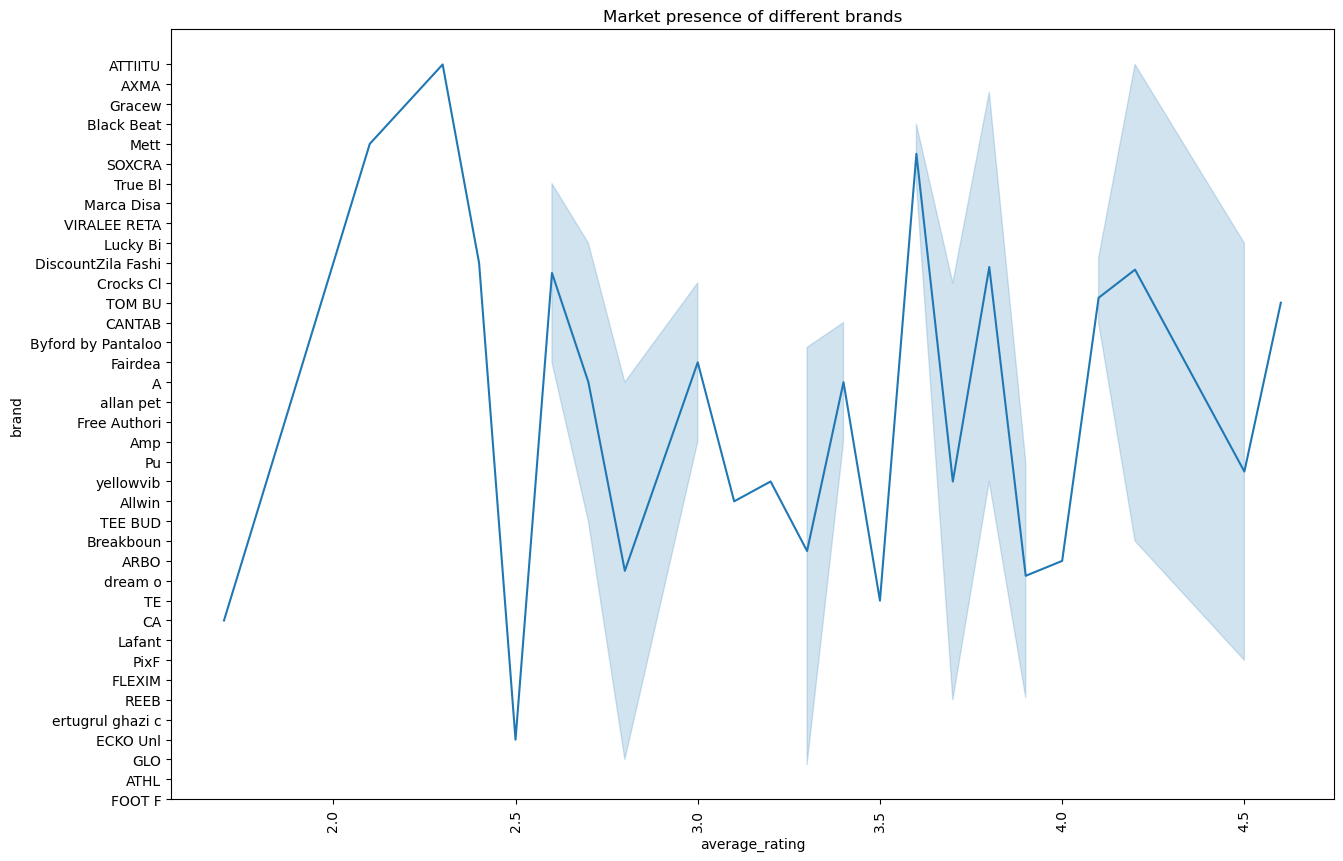

In [9]:
# we take a allsample brand and try seeing if based on the brand does the price rise
plt.figure(figsize=(15, 10))

# Subsample the data for better visualization
subset_df = df.sample(n=60)  # Adjust the number of samples as needed

# Line plot for 'brand'

sns.lineplot(data=subset_df, x='average_rating', y='brand')
plt.xticks(rotation='vertical')
plt.title("Market presence of different brands")
plt.show()

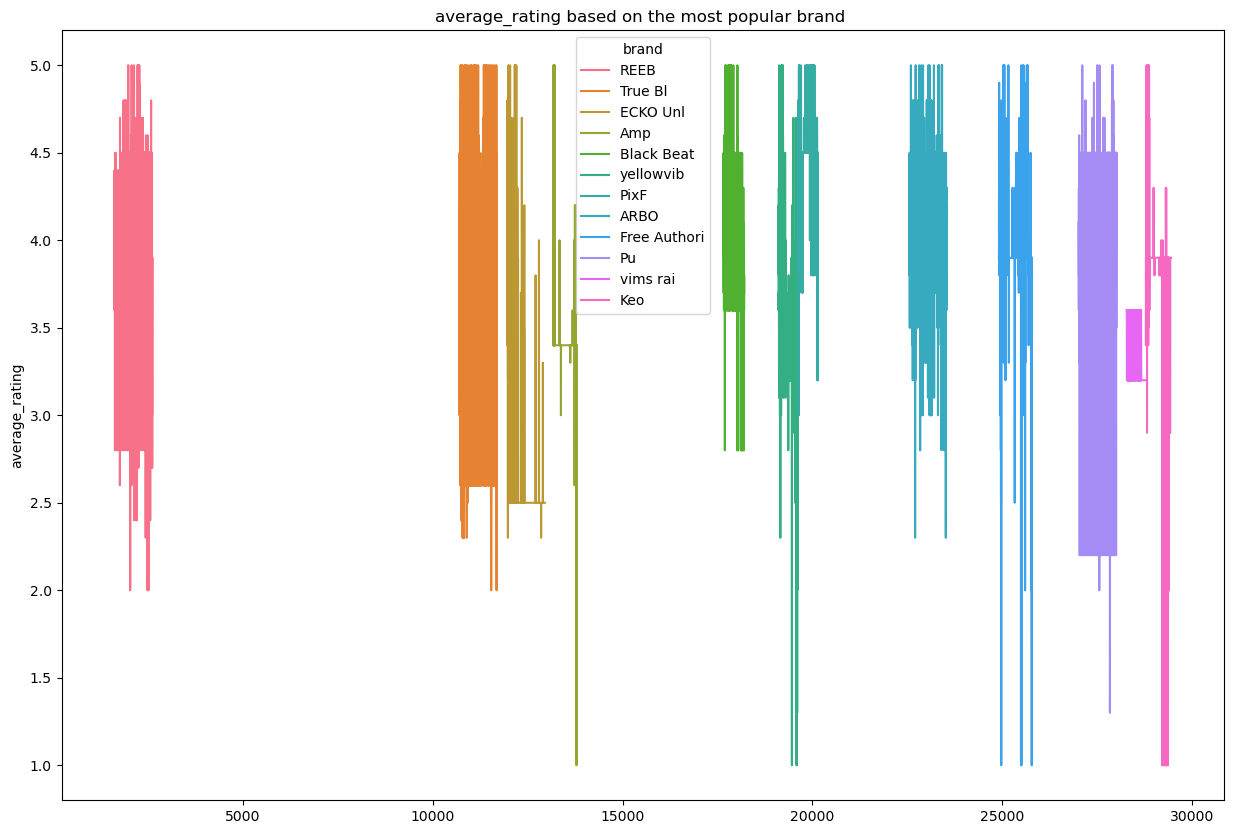

In [10]:
brands_to_plot = ['ARBO', 'Pu', 'True Bl', 'REEB', 'ECKO Unl', 'Free Authori', 'Keo', 'Amp', 'Black Beat', 'PixF', 'yellowvib', 'vims rai']

plt.figure(figsize=(15, 10))

# Filter the DataFrame for the specified brands
filtered_df = df[df['brand'].isin(brands_to_plot)]

# Line plot for 'actual_price'

sns.lineplot(data=filtered_df, x=filtered_df.index, y='average_rating', hue='brand')
plt.title('average_rating based on the most popular brand ')


plt.show()



In [11]:
df['actual_price'] = df['actual_price'].str.replace(',', '')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce').astype('Int64')


In [12]:
# we first find the range of prices for all the brand 
brand_ranges = df.groupby('brand')['actual_price'].agg(['min', 'max'])
brand_ranges.head() 

,min,max
brand,,
A,949,2999
A J STYL,799,1999
A to Z life sty,699,699
A2Z QUALITY GROU,690,2890
ABC ANY BUDY CLE,999,2499


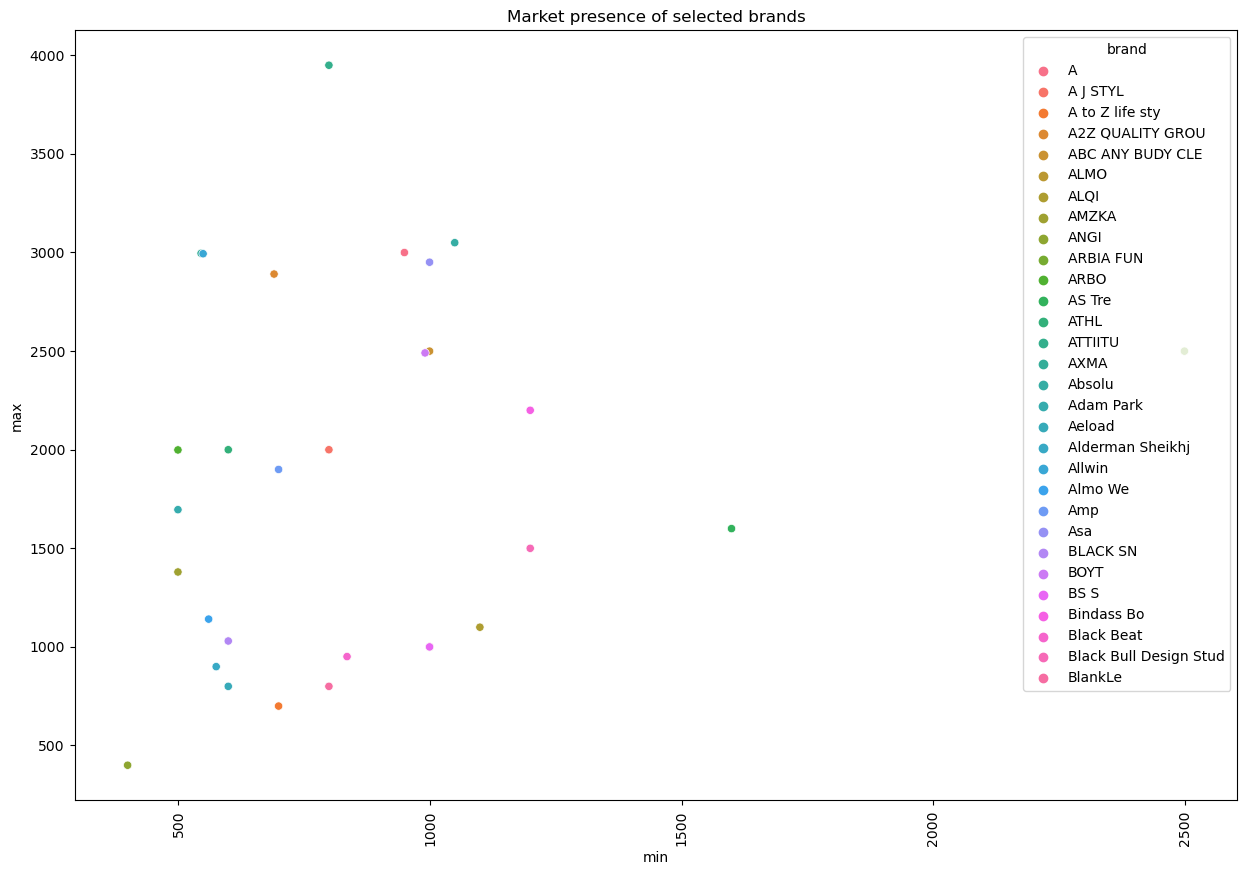

In [13]:
# Filter the brand_ranges DataFrame for the specified brands
brands_filtered = brand_ranges.iloc[0:30]

plt.figure(figsize=(15, 10))

# Scatter plot for filtered brands
sns.scatterplot(data=brands_filtered, x='min', y='max', hue=brands_filtered.index)
plt.xticks(rotation='vertical')
plt.title("Market presence of selected brands")
plt.show()


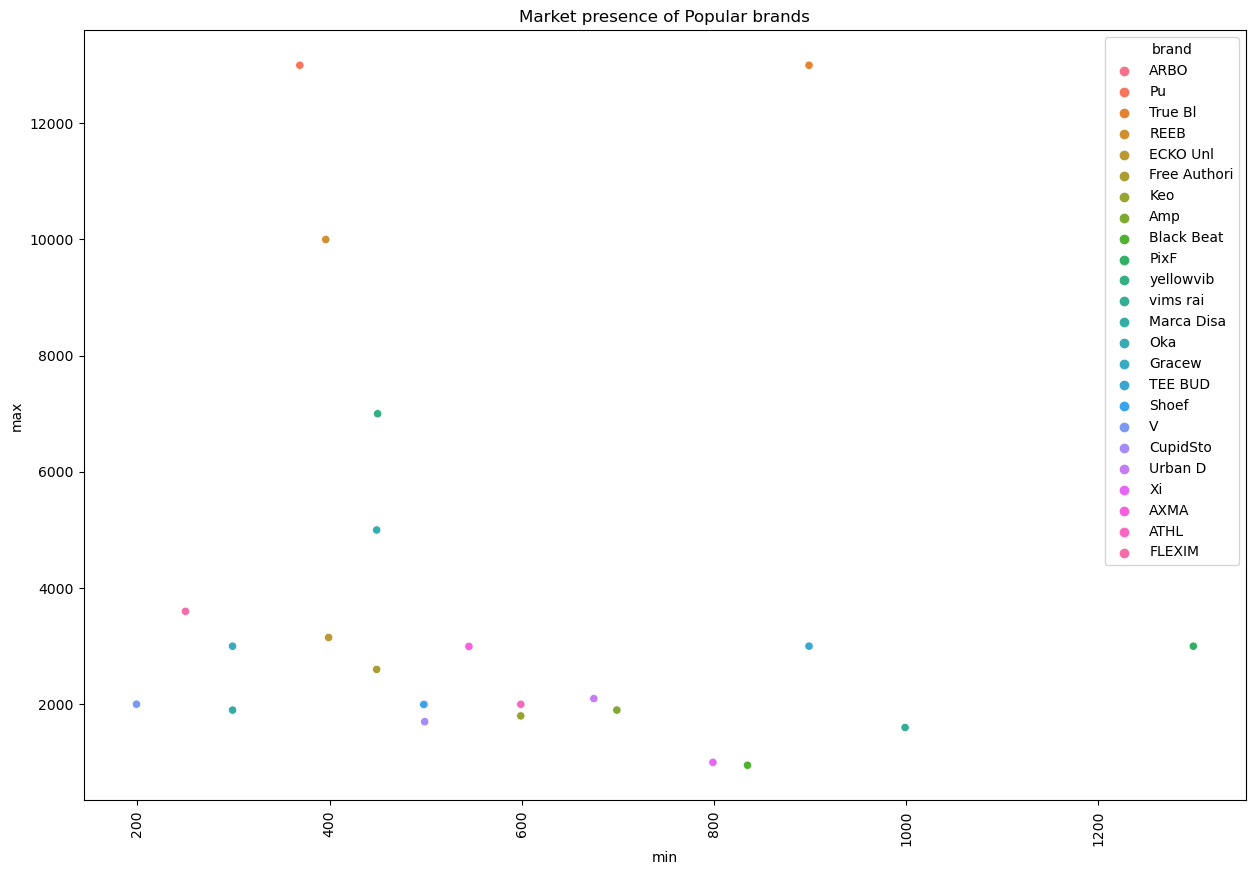

In [14]:
brands_to_plot = ['ARBO', 'Pu', 'True Bl', 'REEB', 'ECKO Unl', 'Free Authori', 'Keo', 'Amp', 'Black Beat', 'PixF', 'yellowvib', 
'vims rai',
'Marca Disa',
'Oka',
 'Gracew',                     
'TEE BUD',                    
'Shoef',                     
'V',                          
'CupidSto',                   
'Urban D',                    
'Xi',                         
'AXMA',                       
'ATHL',                       
'FLEXIM'  ]

# Filter the brand_ranges DataFrame for the specified brands
brands_filtered = brand_ranges.loc[brands_to_plot]

plt.figure(figsize=(15, 10))

# Scatter plot for filtered brands
sns.scatterplot(data=brands_filtered, x='min', y='max', hue=brands_filtered.index)
plt.xticks(rotation='vertical')
plt.title("Market presence of Popular brands")
plt.show()


# *Observation*

<div style="border:1px solid black; padding:10px">
    
<span style="color:green; font-size:32px">Brand analysis:</span>

* ### *Based on the plots above we can clearly see that the brand that appears more frequent or more counts are more expensive as well *

* ### *We can also see that popular brand get great ratings *

</div>



In [15]:
df.head(2)

,Unnamed: 0,_id,actual_price,average_rating,brand,category,crawled_at,description,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url
0,0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,2999,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...
1,1,893e6980-f2a0-531f-b056-34dd63fe912c,1499,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,Yorker trackpants made from 100% rich combed c...,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...


In [16]:
df = df.rename(columns={'Description': 'discount'})


In [17]:
df['discount'] = df.iloc[:, 7]


In [18]:
df['description2'] = df.iloc[:, 8]

In [19]:
df.drop(columns=['description'],inplace=True)

In [20]:
df.head(2)

,Unnamed: 0,_id,actual_price,average_rating,brand,category,crawled_at,discount,images,out_of_stock,pid,product_details,seller,selling_price,sub_category,title,url,description2
0,0,fa8e22d6-c0b6-5229-bb9e-ad52eda39a0a,2999,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EA7H5FYZH,"[{'Style Code': '1005COMBO2'}, {'Closure': 'El...",Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,https://www.flipkart.com/yorker-solid-men-mult...,69% off
1,1,893e6980-f2a0-531f-b056-34dd63fe912c,1499,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,['https://rukminim1.flixcart.com/image/128/128...,False,TKPFCZ9EJZV2UVRZ,"[{'Style Code': '1005BLUE'}, {'Closure': 'Draw...",Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,https://www.flipkart.com/yorker-solid-men-blue...,66% off


In [21]:
df.drop(columns=['Unnamed: 0'],inplace=True)
df.drop(columns=['_id'],inplace=True)
df.drop(columns=['images'],inplace=True)
df.drop(columns=['pid'],inplace=True)
df.drop(columns=['product_details'],inplace=True)


In [22]:
df.drop(columns=['url'],inplace=True)

In [23]:
df.head(2)

,actual_price,average_rating,brand,category,crawled_at,discount,out_of_stock,seller,selling_price,sub_category,title,description2
0,2999,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,False,Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,69% off
1,1499,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,False,Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,66% off


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   actual_price    29137 non-null  Int64  
 1   average_rating  27554 non-null  float64
 2   brand           27932 non-null  object 
 3   category        30000 non-null  object 
 4   crawled_at      30000 non-null  object 
 5   discount        29059 non-null  object 
 6   out_of_stock    30000 non-null  bool   
 7   seller          28259 non-null  object 
 8   selling_price   29998 non-null  object 
 9   sub_category    30000 non-null  object 
 10  title           30000 non-null  object 
 11  description2    29059 non-null  object 
dtypes: Int64(1), bool(1), float64(1), object(9)
memory usage: 2.6+ MB


In [25]:
df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce').astype('Int64')



In [26]:
df['discounted_price']= df['actual_price'] - df['selling_price']

In [27]:
df.head(2)

,actual_price,average_rating,brand,category,crawled_at,discount,out_of_stock,seller,selling_price,sub_category,title,description2,discounted_price
0,2999,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,False,Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,69% off,2078
1,1499,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,False,Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,66% off,1000


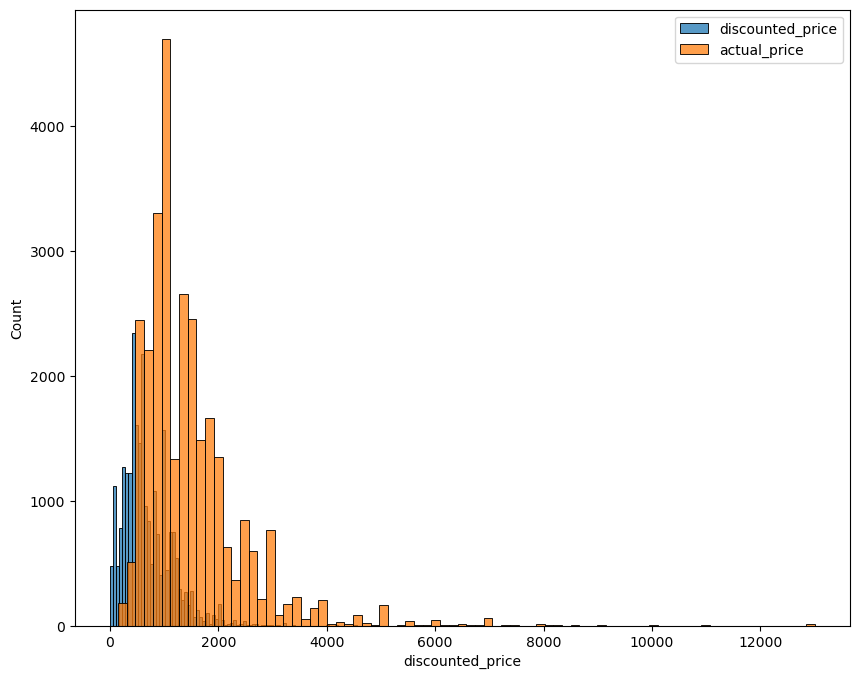

In [28]:
plt.figure(figsize=(10 , 8))
sns.histplot(df.iloc[: , -1],bins=80,label='discounted_price')
sns.histplot(df.iloc[: ,0],bins=80,label='actual_price')
plt.legend()
plt.show()


In [29]:
# finding the average 
average_rating = df['average_rating'].mean()
average_original_price=df['actual_price'].mean()
discounted_price = df['discounted_price'].mean()
selling_price =df['selling_price'].mean()

columns2 = pd.DataFrame({
    "average_rating": [average_rating],
    "average_original_price": [average_original_price],
    "discounted_price": [discounted_price],
    "selling_price": [selling_price]
})


columns2


,average_rating,average_original_price,discounted_price,selling_price
0,3.641972,1472.617703,678.394607,536.31172


# *Observation*

<div style="border:1px solid black; padding:10px">
    
<span style="color:green; font-size:32px">selling price analysis:</span>

* ### *On an average the rating is almost at 3 for most of the brands*

* ### *On an average the original_price is almost at 1472 for most of the brands*

* ### *On an average the discounted_price is almost at 678 for most of the brands*
 
* ### *On an average the selling price is almost at 500 +  for most of the brands*

</div>


In [30]:
df.head(2)

,actual_price,average_rating,brand,category,crawled_at,discount,out_of_stock,seller,selling_price,sub_category,title,description2,discounted_price
0,2999,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:51",69% off,False,Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,69% off,2078
1,1499,3.9,York,Clothing and Accessories,"02/10/2021, 20:11:52",66% off,False,Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,66% off,1000


In [31]:
df.drop(columns=['crawled_at'],inplace=True)

In [32]:
df.head(2)

,actual_price,average_rating,brand,category,discount,out_of_stock,seller,selling_price,sub_category,title,description2,discounted_price
0,2999,3.9,York,Clothing and Accessories,69% off,False,Shyam Enterprises,921,Bottomwear,Solid Men Multicolor Track Pants,69% off,2078
1,1499,3.9,York,Clothing and Accessories,66% off,False,Shyam Enterprises,499,Bottomwear,Solid Men Blue Track Pants,66% off,1000


In [33]:
df['out_of_stock'].value_counts()

False    28258
True      1742
Name: out_of_stock, dtype: int64

<__array_function__ internals>:180: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


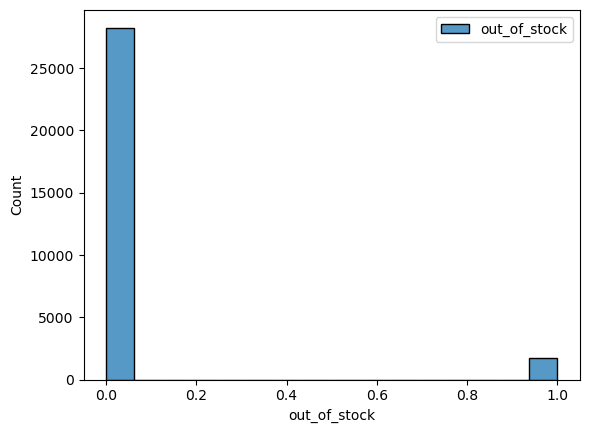

In [34]:
sns.histplot(df['out_of_stock'],label='out_of_stock')
plt.legend()
plt.show()

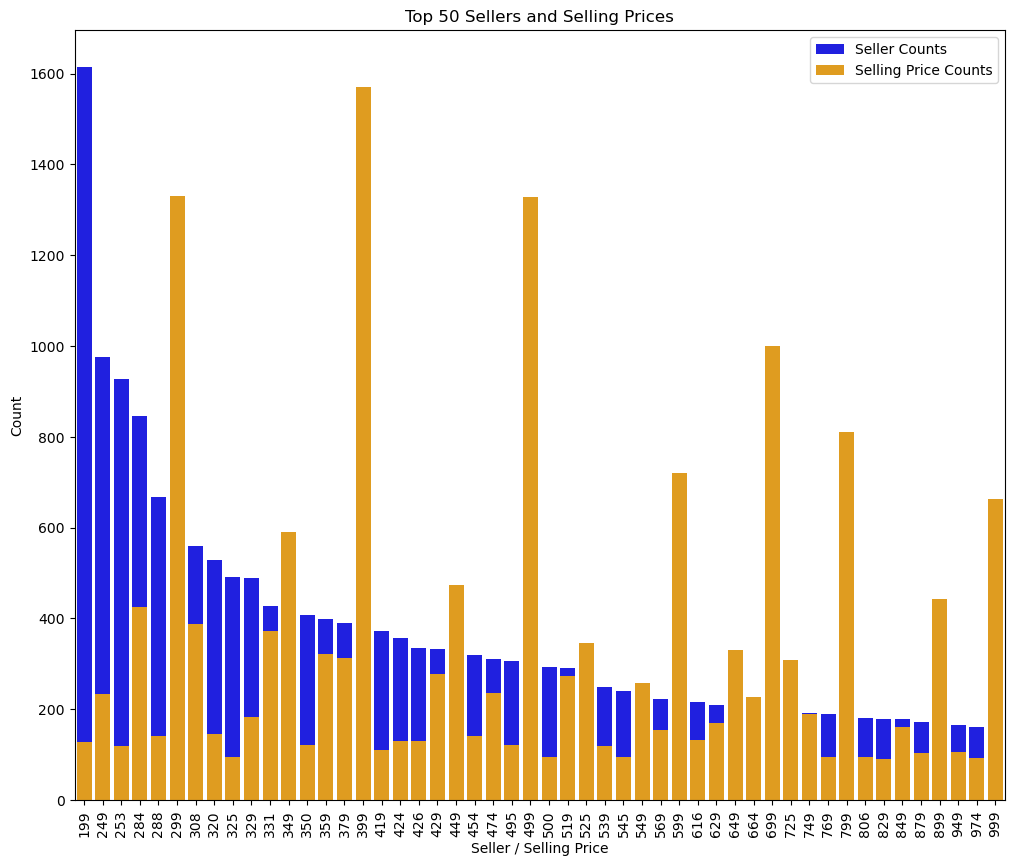

In [35]:
# Consider top 50 sellers
seller_counts = df['seller'].value_counts().head(50)
# Consider top 50 selling prices
selling_price_counts = df['selling_price'].value_counts().head(50)

plt.figure(figsize=(12, 10))
sns.barplot(x=seller_counts.index, y=seller_counts.values, color='blue', label='Seller Counts')
sns.barplot(x=selling_price_counts.index, y=selling_price_counts.values, color='orange', label='Selling Price Counts')
plt.xticks(rotation='vertical')
plt.xlabel('Seller / Selling Price')
plt.ylabel('Count')
plt.title('Top 50 Sellers and Selling Prices')
plt.legend()
plt.show()



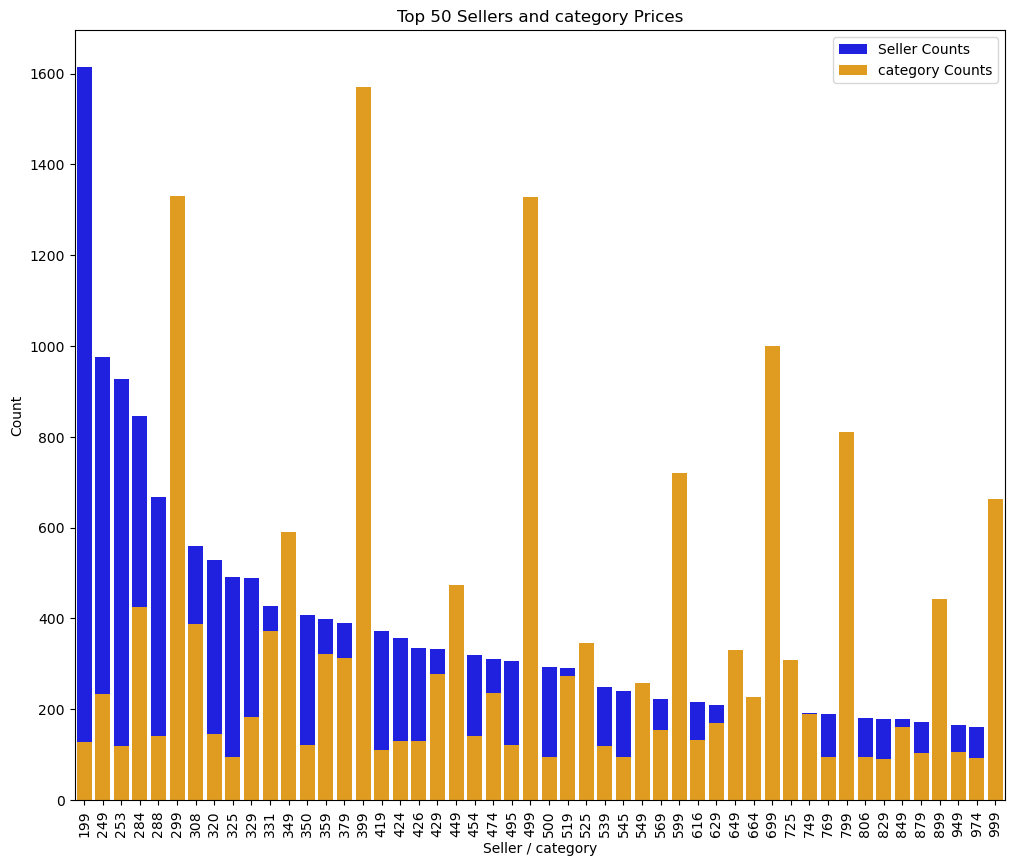

In [36]:
# Consider top 50 sellers
seller_counts = df['seller'].value_counts().head(50)
# Consider top 50 selling prices
category_counts = df['category'].value_counts().head(50)

plt.figure(figsize=(12, 10))
sns.barplot(x=seller_counts.index, y=seller_counts.values, color='blue', label='Seller Counts')
sns.barplot(x=selling_price_counts.index, y=selling_price_counts.values, color='orange', label='category Counts')
plt.xticks(rotation='vertical')
plt.xlabel('Seller / category')
plt.ylabel('Count')
plt.title('Top 50 Sellers and category Prices')
plt.legend()
plt.show()

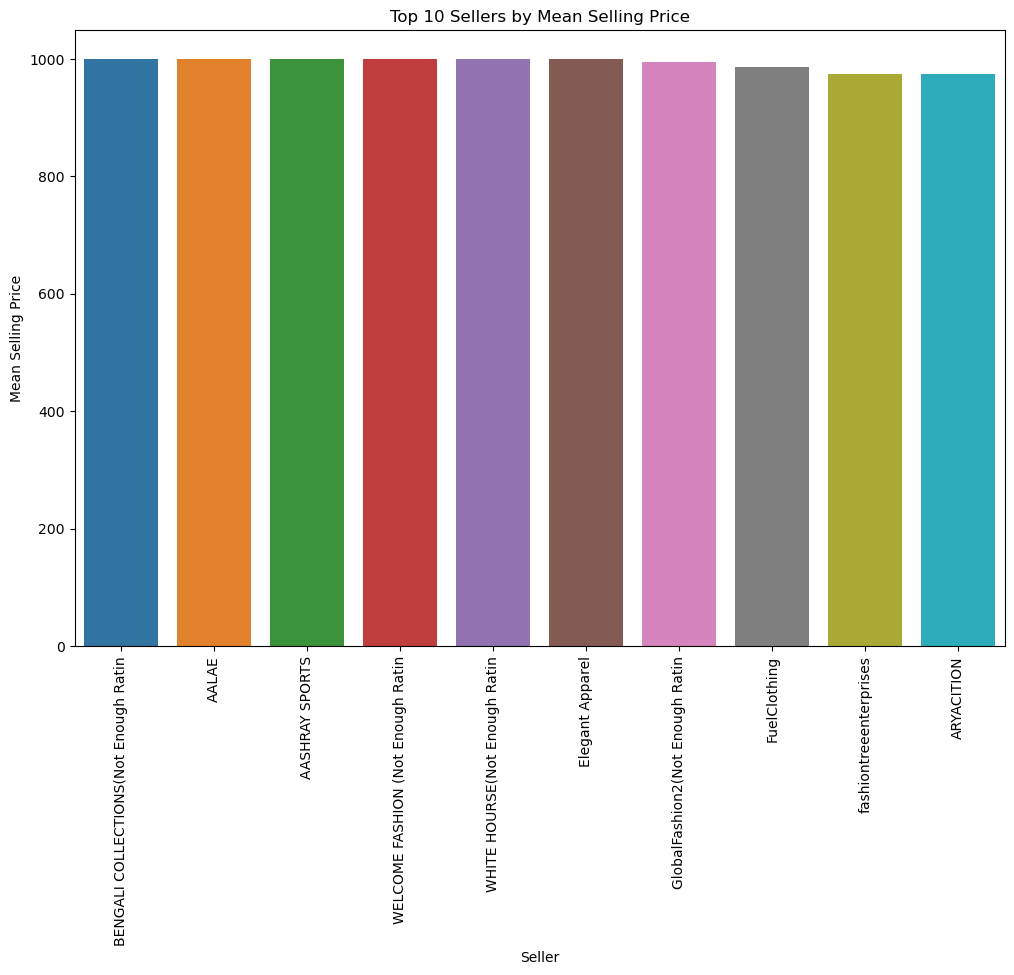

In [37]:
seller_stats = df.groupby('seller')['selling_price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 8))
sns.barplot(x=seller_stats.index, y=seller_stats.values)
plt.xticks(rotation='vertical')
plt.xlabel('Seller')
plt.ylabel('Mean Selling Price')
plt.title('Top 10 Sellers by Mean Selling Price')
plt.show()